**# U7 — DS Lifecycle & Data Sources: Lab**

**Data Engineering & Preparation (Phase C begins)** — the project lifecycle, CRISP-DM, data types, sources, formats & ingestion

_Day 3–4 · Phase C · The first step before any modelling: plan the project and get the data in._

#objectives

By the end of this lab you will be able to:

Recall the stages of the data science lifecycle and put a project in order

Map the lifecycle onto the six CRISP-DM phases

Classify data as structured, semi-structured or unstructured

Load data from a CSV file and from a JSON source into a pandas DataFrame

Pull data from a public REST API and inspect it with .head(), .shape and .dtypes

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [1]:
# Core imports for the whole lab
import pandas as pd
import json

print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


#1. The data science lifecycle

In [2]:
# -----------------------------------------------------------
# 🔹 1A. THE EIGHT STAGES, IN ORDER
# -----------------------------------------------------------

lifecycle = [
    'Define',    # frame the business problem
    'Collect',   # gather & ingest data
    'Prepare',   # clean & transform
    'Explore',   # EDA & visualise
    'Model',     # train algorithms
    'Evaluate',  # test & validate
    'Deploy',    # serve predictions
    'Monitor',   # watch & maintain  (then loop back!)
]
for i, stage in enumerate(lifecycle, start=1):
    print(f'{i}. {stage}')

1. Define
2. Collect
3. Prepare
4. Explore
5. Model
6. Evaluate
7. Deploy
8. Monitor


In [3]:
# -----------------------------------------------------------
# 🔹 1B. WHAT HAPPENS AT EACH STAGE
# -----------------------------------------------------------

what_happens = {
    'Define':   'turn a business question into an ML problem',
    'Collect':  'pull data from files, databases, APIs',
    'Prepare':  'clean missing values, fix types, engineer features',
    'Explore':  'summarise & visualise to find patterns',
    'Model':    'train and tune algorithms',
    'Evaluate': 'measure performance on unseen data',
    'Deploy':   'put the model into production',
    'Monitor':  'track performance and retrain as needed',
}
for stage, desc in what_happens.items():
    print(f'{stage:9s} -> {desc}')

Define    -> turn a business question into an ML problem
Collect   -> pull data from files, databases, APIs
Prepare   -> clean missing values, fix types, engineer features
Explore   -> summarise & visualise to find patterns
Model     -> train and tune algorithms
Evaluate  -> measure performance on unseen data
Deploy    -> put the model into production
Monitor   -> track performance and retrain as needed


#### 🧪 LAB EXERCISE 1 — Order the lifecycle

A teammate listed the stages out of order. Sort them back into the correct lifecycle order.
1. Use the `lifecycle` list above as the reference order.
2. Sort `shuffled` by each item's position in `lifecycle`.
3. Print the corrected order and confirm it equals `lifecycle`.

In [5]:
shuffled = ['Model', 'Define', 'Deploy', 'Collect', 'Monitor',
            'Prepare', 'Evaluate', 'Explore']

# 1 & 2. sort 'shuffled' by position in 'lifecycle'
sorted_shuffled = sorted(shuffled, key=lifecycle.index)
print('Sorted shuffled list:', sorted_shuffled)

# 3. confirm it matches the reference order
print('Does sorted_shuffled equal lifecycle?', sorted_shuffled == lifecycle)

Sorted shuffled list: ['Define', 'Collect', 'Prepare', 'Explore', 'Model', 'Evaluate', 'Deploy', 'Monitor']
Does sorted_shuffled equal lifecycle? True


#2. CRISP-DM

In [6]:
# -----------------------------------------------------------
# 🔹 2A. THE SIX CRISP-DM PHASES
# -----------------------------------------------------------

crisp_dm = [
    'Business Understanding',
    'Data Understanding',
    'Data Preparation',
    'Modeling',
    'Evaluation',
    'Deployment',
]
for i, phase in enumerate(crisp_dm, start=1):
    print(f'{i}. {phase}')

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


In [7]:
# -----------------------------------------------------------
# 🔹 2B. MAP LIFECYCLE STAGES -> CRISP-DM PHASES
# -----------------------------------------------------------

# Several lifecycle stages can fall under one CRISP-DM phase.
mapping = {
    'Define':   'Business Understanding',
    'Collect':  'Data Understanding',
    'Explore':  'Data Understanding',
    'Prepare':  'Data Preparation',
    'Model':    'Modeling',
    'Evaluate': 'Evaluation',
    'Deploy':   'Deployment',
    'Monitor':  'Deployment',
}
for stage, phase in mapping.items():
    print(f'{stage:9s} -> {phase}')

Define    -> Business Understanding
Collect   -> Data Understanding
Explore   -> Data Understanding
Prepare   -> Data Preparation
Model     -> Modeling
Evaluate  -> Evaluation
Deploy    -> Deployment
Monitor   -> Deployment


The CRISP-DM (Cross-Industry Standard Process for Data Mining) framework outlines six phases for a data science project, providing a structured approach to solving business problems with data:

**Business Understanding:** This initial phase focuses on understanding the project objectives and requirements from a business perspective, then converting this knowledge into a data mining problem definition.
**Data Understanding:** This phase involves collecting data, exploring it to become familiar with it, identifying data quality problems, and discovering initial insights or patterns.
**Data Preparation:** The data collected is prepared for modeling. This includes data cleaning (handling missing values, inconsistencies), data transformation (feature engineering, normalization), and data integration.
**Modeling:** In this phase, various modeling techniques are selected and applied. This often involves building and training machine learning models based on the prepared data.
**Evaluation:** Once models are built, they are evaluated against the business objectives to determine if they effectively achieve the project goals. This involves assessing the model's performance and identifying any issues.
**Deployment:** The final phase involves deploying the model into a production environment, which means integrating it into business processes. This can range from generating reports to implementing a real-time predictive system. It also includes planning for monitoring and maintenance.

#### 🧪 LAB EXERCISE 2 — CRISP-DM grouping

Using the `mapping` above:
1. Build a dictionary `phase -> [stages]` (which lifecycle stages belong to each CRISP-DM phase).
2. Print each phase with the stages under it.
3. Which CRISP-DM phase covers the **most** lifecycle stages?

In [8]:
grouped = {}
for stage, phase in mapping.items():
    if phase not in grouped:
        grouped[phase] = []
    grouped[phase].append(stage)

# 2. print phase -> stages
print('Lifecycle Stages grouped by CRISP-DM Phase:')
for phase, stages in grouped.items():
    print(f'{phase}: {stages}')

# 3. which phase has the most stages?  (max by length)
most_stages_phase = max(grouped, key=lambda phase: len(grouped[phase]))
print(f'\nThe CRISP-DM phase with the most lifecycle stages is: {most_stages_phase} (with {len(grouped[most_stages_phase])} stages)')

Lifecycle Stages grouped by CRISP-DM Phase:
Business Understanding: ['Define']
Data Understanding: ['Collect', 'Explore']
Data Preparation: ['Prepare']
Modeling: ['Model']
Evaluation: ['Evaluate']
Deployment: ['Deploy', 'Monitor']

The CRISP-DM phase with the most lifecycle stages is: Data Understanding (with 2 stages)


#3. Classifying data types

In [10]:
# -----------------------------------------------------------
# 🔹 3A. STRUCTURED / SEMI-STRUCTURED / UNSTRUCTURED
# -----------------------------------------------------------

examples = {
    'a SQL users table':        'structured',
    'a CSV of sales':           'structured',
    'a JSON API response':      'semi-structured',
    'an XML config file':       'semi-structured',
    'a folder of photos':       'unstructured',
    'customer review text':     'unstructured',
}
for item, kind in examples.items():
    print(f'{kind:16s} <- {item}')

structured       <- a SQL users table
structured       <- a CSV of sales
semi-structured  <- a JSON API response
semi-structured  <- an XML config file
unstructured     <- a folder of photos
unstructured     <- customer review text


In [12]:
# -----------------------------------------------------------
# 🔹 3B. A SIMPLE CLASSIFIER
# -----------------------------------------------------------

def classify(fmt):
    fmt = fmt.lower()
    if fmt in ('csv', 'sql', 'parquet', 'excel', 'xlsx'):
        return 'structured'
    if fmt in ('json', 'xml', 'yaml', 'log'):
        return 'semi-structured'
    return 'unstructured'   # text, image, audio, video, ...

for fmt in ['csv', 'json', 'jpg', 'sql', 'xml', 'mp3']:
    print(f'{fmt:6s} -> {classify(fmt)}')

csv    -> structured
json   -> semi-structured
jpg    -> unstructured
sql    -> structured
xml    -> semi-structured
mp3    -> unstructured


#### 🧪 LAB EXERCISE 3 — Classify these datasets

1. Use `classify()` to label each format in `to_label`.
2. Count how many fall into each category.
3. In a comment, name one machine-learning task that uses **unstructured** data.

In [14]:
import collections

to_label = ['parquet', 'yaml', 'png', 'csv', 'wav', 'json', 'txt']

# 1. classify each one
classified_data = [(fmt, classify(fmt)) for fmt in to_label]
print('Classified Data:')
for fmt, category in classified_data:
    print(f'{fmt:7s} -> {category}')

# 2. count per category  (hint: collections.Counter)
categories = [category for fmt, category in classified_data]
category_counts = collections.Counter(categories)
print('\nCategory Counts:')
for category, count in category_counts.items():
    print(f'{category:15s}: {count}')

# 3. An ML task that uses unstructured data:
# Natural Language Processing (NLP) tasks like sentiment analysis or text summarization using customer review text.

Classified Data:
parquet -> structured
yaml    -> semi-structured
png     -> unstructured
csv     -> structured
wav     -> unstructured
json    -> semi-structured
txt     -> unstructured

Category Counts:
structured     : 2
semi-structured: 2
unstructured   : 3


#4. Loading data from files (CSV & JSON)

In [16]:
# -----------------------------------------------------------
# 🔹 4A. WRITE A CSV, THEN READ IT BACK
# -----------------------------------------------------------

# (in real life the CSV already exists; here we create one so the lab is self-contained)
sample = pd.DataFrame({
    'name':   ['Ana', 'Bo', 'Cy', 'Di'],
    'age':    [30, 25, 41, 38],
    'city':   ['Pune', 'Delhi', 'Pune', 'Hyderabad'],
    'spend':  [120.5, 80.0, 200.2, 150.0],
})
sample.to_csv('people.csv', index=False)   # write

df = pd.read_csv('people.csv')             # read back
df.head()

,name,age,city,spend
0,Ana,30,Pune,120.5
1,Bo,25,Delhi,80.0
2,Cy,41,Pune,200.2
3,Di,38,Hyderabad,150.0


In [17]:
# -----------------------------------------------------------
# 🔹 4B. ALWAYS INSPECT A NEW DATAFRAME
# -----------------------------------------------------------

print('shape :', df.shape)        # (rows, columns)
print()
print('dtypes:')
print(df.dtypes)                  # the type of each column
print()
df.describe(include='all')        # quick summary

shape : (4, 4)

dtypes:
name      object
age        int64
city      object
spend    float64
dtype: object



,name,age,city,spend
count,4,4.000000,4,4.000000
unique,4,NaN,3,NaN
top,Ana,NaN,Pune,NaN
freq,1,NaN,2,NaN
mean,NaN,33.500000,NaN,137.675000
std,NaN,7.325754,NaN,50.605229
min,NaN,25.000000,NaN,80.000000
25%,NaN,28.750000,NaN,110.375000
50%,NaN,34.000000,NaN,135.250000
75%,NaN,38.750000,NaN,162.550000


In [18]:
# -----------------------------------------------------------
# 🔹 4C. READING JSON (semi-structured -> table)
# -----------------------------------------------------------

# JSON often comes nested; json_normalize flattens it into columns
records = [
    {'id': 1, 'user': {'name': 'Ana', 'city': 'Pune'}, 'spend': 120.5},
    {'id': 2, 'user': {'name': 'Bo',  'city': 'Delhi'}, 'spend': 80.0},
]
json_df = pd.json_normalize(records)   # note the 'user.name', 'user.city' columns
json_df

,id,spend,user.name,user.city
0,1,120.5,Ana,Pune
1,2,80.0,Bo,Delhi


In [19]:
import pandas as pd

# Create a sample DataFrame (if you don't have one)
sample_df = pd.DataFrame({
    'product': ['Laptop', 'Mouse', 'Keyboard'],
    'price': [1200.00, 25.50, 75.00],
    'in_stock': [True, True, False]
})

# Write the DataFrame to a JSON file
sample_df.to_json('products.json', orient='records', indent=4)
print("DataFrame written to 'products.json'")

# Optionally, read it back to verify
read_json_df = pd.read_json('products.json')
print("\nDataFrame read back from 'products.json':")
display(read_json_df.head())

DataFrame written to 'products.json'

DataFrame read back from 'products.json':


,product,price,in_stock
0,Laptop,1200.0,True
1,Mouse,25.5,True
2,Keyboard,75.0,False


#### 🧪 LAB EXERCISE 4 — Round-trip a CSV

1. Create a small DataFrame of 3 products (`product`, `price`, `in_stock`).
2. Write it to `products.csv`, then read it back into a new DataFrame.
3. Print its `.shape` and `.dtypes`.

In [20]:
# 1. build the DataFrame
product_df = pd.DataFrame({
    'product': ['Chair', 'Desk', 'Lamp'],
    'price': [50.00, 150.00, 25.00],
    'in_stock': [True, False, True]
})

# 2. write to 'products.csv' then read it back
product_df.to_csv('products.csv', index=False)
read_product_df = pd.read_csv('products.csv')

# 3. inspect shape & dtypes
print('Shape of the read DataFrame:', read_product_df.shape)
print('\nData types of the read DataFrame:')
print(read_product_df.dtypes)

Shape of the read DataFrame: (3, 3)

Data types of the read DataFrame:
product      object
price       float64
in_stock       bool
dtype: object


#5. Loading data from a REST API

In [22]:
# -----------------------------------------------------------
# 🔹 5A. FETCH JSON FROM A PUBLIC API
# -----------------------------------------------------------
import requests

API_URL = 'https://jsonplaceholder.typicode.com/users'   # a free demo API

# Pattern: GET the URL -> parse JSON -> build a DataFrame.
# We wrap it in try/except so the lab still runs if you're offline;
# in that case we fall back to a small inline sample.
try:
    resp = requests.get(API_URL, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    print('Fetched', len(data), 'records from the live API.')
except Exception as e:
    print('Network unavailable (', type(e).__name__, ') - using inline sample.')
    data = [
        {'id': 1, 'name': 'Leanne Graham',  'username': 'Bret',     'email': 'sincere@april.biz'},
        {'id': 2, 'name': 'Ervin Howell',   'username': 'Antonette','email': 'shanna@melissa.tv'},
        {'id': 3, 'name': 'Clementine Bauch','username': 'Samantha','email': 'nathan@yesenia.net'},
    ]

api_df = pd.json_normalize(data)
api_df.head()

Fetched 10 records from the live API.


,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems


In [23]:
# -----------------------------------------------------------
# 🔹 5B. INSPECT & SELECT FROM THE API DATA
# -----------------------------------------------------------

print('shape:', api_df.shape)
# keep just a few useful columns (these exist in both live & sample data)
cols = [c for c in ['id', 'name', 'username', 'email'] if c in api_df.columns]
api_df[cols].head()

shape: (10, 15)


,id,name,username,email
0,1,Leanne Graham,Bret,Sincere@april.biz
1,2,Ervin Howell,Antonette,Shanna@melissa.tv
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca


#### 🧪 LAB EXERCISE 5 — Pull from an API

The same demo API has a `/posts` endpoint (`https://jsonplaceholder.typicode.com/posts`).
1. Fetch it with `requests.get(...).json()` (wrap in try/except like the demo).
2. Build a DataFrame with `pd.json_normalize`.
3. Print its `.shape` and the first 3 rows.

_Tip: if you're offline, reuse the inline-sample fallback pattern from 5A._

In [25]:
POSTS_URL = 'https://jsonplaceholder.typicode.com/posts'

# 1. fetch (try/except with a small inline fallback)
try:
    resp_posts = requests.get(POSTS_URL, timeout=10)
    resp_posts.raise_for_status()
    posts_data = resp_posts.json()
    print('Fetched', len(posts_data), 'records from the live API.')
except Exception as e:
    print('Network unavailable (', type(e).__name__, ') - using inline sample for posts.')
    posts_data = [
        {'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'},
        {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'},
        {'userId': 1, 'id': 3, 'title': 'ea molestias quasi exercitationem rerum qui', 'body': 'et iusto sed quo iure\nvoluptatem occaecati omnis eligendi aut ad\nvoluptatem doloribus vel accusantium quis pariatur\nmolestiae porro eius odio et labore et velit aut'},
    ]

# 2. build the DataFrame
posts_df = pd.json_normalize(posts_data)

# 3. shape + first 3 rows
print('\nShape of posts DataFrame:', posts_df.shape)
print('\nFirst 3 rows of posts DataFrame:')
display(posts_df.head(3))

Fetched 100 records from the live API.

Shape of posts DataFrame: (100, 4)

First 3 rows of posts DataFrame:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...


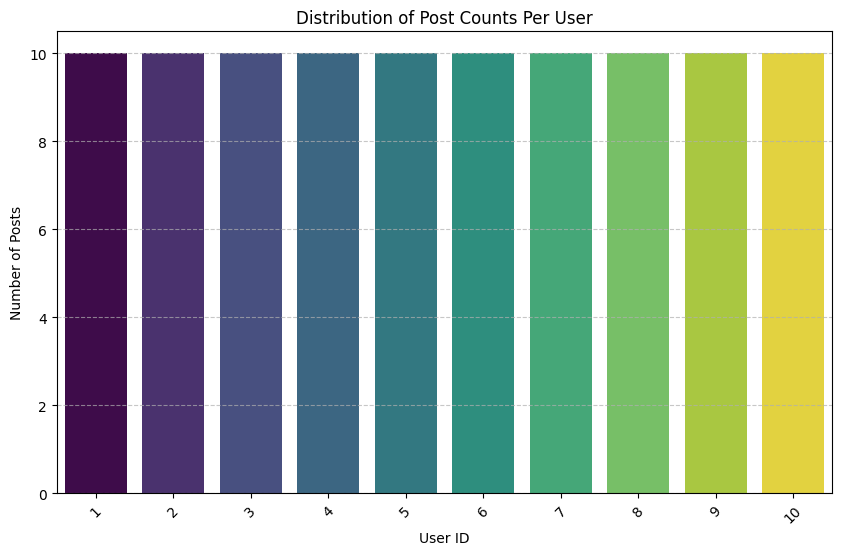

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate post counts per user
posts_per_user = posts_df.groupby('userId')['id'].count().reset_index()
posts_per_user.columns = ['userId', 'post_count']

# Plot the distribution of post counts per user
plt.figure(figsize=(10, 6))
sns.barplot(x='userId', y='post_count', data=posts_per_user, palette='viridis', hue='userId', legend=False)
plt.title('Distribution of Post Counts Per User')
plt.xlabel('User ID')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#📘 Summary — DS Lifecycle & Data Sources toolkit

| Concept | What it is | Key idea / call |
| ------- | ---------- | --------------- |
| **Lifecycle** | the 8 project stages | Define → Collect → Prepare → Explore → Model → Evaluate → Deploy → Monitor |
| **CRISP-DM** | the standard framework | 6 iterative phases |
| **Data types** | shapes of data | structured / semi-structured / unstructured |
| **CSV / files** | flat & columnar files | `pd.read_csv`, `pd.read_parquet` |
| **JSON** | nested, semi-structured | `pd.json_normalize` |
| **API** | data over HTTP | `requests.get(url).json()` → DataFrame |
| **Always** | inspect new data | `.head()` · `.shape` · `.dtypes` |

**Homework (self-paced):** order the lifecycle · group stages by CRISP-DM phase · classify datasets · round-trip a CSV · pull a second API endpoint into a DataFrame.

**Next — Phase C continues:** U8 *Data Cleaning & Preprocessing* (handling messy real data) and U9 *Exploratory Data Analysis*.

#### 🧪 LAB EXERCISE 6 — Pull a second API endpoint into a DataFrame

The same demo API has a `/comments` endpoint (`https://jsonplaceholder.typicode.com/comments`).
1. Fetch it with `requests.get(...).json()` (wrap in try/except like the demo).
2. Build a DataFrame with `pd.json_normalize`.
3. Print its `.shape` and the first 3 rows.

In [30]:
COMMENTS_URL = 'https://jsonplaceholder.typicode.com/comments'

# 1. fetch (try/except with a small inline fallback)
try:
    resp_comments = requests.get(COMMENTS_URL, timeout=10)
    resp_comments.raise_for_status()
    comments_data = resp_comments.json()
    print('Fetched', len(comments_data), 'records from the live API.')
except Exception as e:
    print('Network unavailable (', type(e).__name__, ') - using inline sample for comments.')
    comments_data = [
        {'postId': 1, 'id': 1, 'name': 'id labore ex et quam laborum', 'email': 'Eliseo@gardner.biz', 'body': 'laudantium enim quasi est quidem magnam voluptate ipsam eos\ntempora quo necessitatibus dolor quam autem quasi\nreiciendis et nam sapiente accusantium'},
        {'postId': 1, 'id': 2, 'name': 'quo vero reiciendis velit similique earum', 'email': 'Jayne_Kuhic@sydney.com', 'body': 'est natus enim nihil est dolore omnis voluptatem non alias sit\nautem quidem eum et in quasi\nrepellendus est et non ex nemo eos ut eum'},
        {'postId': 1, 'id': 3, 'name': 'odio adipisci rerum aut animi', 'email': 'Nikita@garfield.biz', 'body': 'quia molestiae et eius aut in quibusdam enim voluptatem rerum pariatur\naut nihil vel quod mi nemo vel totam\nregardium qui sit et aut vel neque'}
    ]

# 2. build the DataFrame
comments_df = pd.json_normalize(comments_data)

# 3. shape + first 3 rows
print('\nShape of comments DataFrame:', comments_df.shape)
print('\nFirst 3 rows of comments DataFrame:')
display(comments_df.head(3))

Fetched 500 records from the live API.

Shape of comments DataFrame: (500, 5)

First 3 rows of comments DataFrame:


,postId,id,name,email,body
0,1,1,id labore ex et quam laborum,Eliseo@gardner.biz,laudantium enim quasi est quidem magnam volupt...
1,1,2,quo vero reiciendis velit similique earum,Jayne_Kuhic@sydney.com,est natus enim nihil est dolore omnis voluptat...
2,1,3,odio adipisci rerum aut animi,Nikita@garfield.biz,quia molestiae reprehenderit quasi aspernatur\...


In [31]:
comments_per_post = comments_df['postId'].value_counts()
display(comments_per_post.head())

,count
postId,
1,5
2,5
3,5
4,5
5,5
